# RRT* — Baseline Planner

## What is RRT*?

RRT* (Rapidly-exploring Random Tree Star) is an **asymptotically optimal** sampling-based motion planning algorithm introduced by Karaman & Frazzoli (2011). It builds on the original RRT algorithm by adding two key steps — **parent selection** and **rewiring** — that together guarantee the path cost converges to the optimum as the number of samples grows.

## Algorithm Overview

At each iteration, RRT* does the following:

1. **Sample** a random configuration $q_\text{rand}$ from the free configuration space $\mathcal{Q}_\text{free}$ (with a small probability of sampling the goal directly — the *goal bias*)
2. **Find the nearest node** $q_\text{near}$ already in the tree
3. **Steer** from $q_\text{near}$ toward $q_\text{rand}$ by at most a fixed step size $\eta$, producing a candidate new node $q_\text{new}$
4. **Collision check** the edge $q_\text{near} \to q_\text{new}$; discard if it intersects an obstacle
5. **Choose the best parent**: within a shrinking ball of radius $r_n = \min\left(\gamma \sqrt{\frac{\log n}{n}},\ \eta\right)$ around $q_\text{new}$, find the node that minimises the total cost from the root:
$$c_\text{new} = \min_{q \in \mathcal{N}(q_\text{new},\ r_n)} \left[ c(q) + \|q_\text{new} - q\| \right]$$
6. **Add** $q_\text{new}$ to the tree with the chosen parent
7. **Rewire**: for each node $q'$ in the same ball, check if routing through $q_\text{new}$ reduces $q'$'s cost-to-root. If so, update $q'$'s parent to $q_\text{new}$

The rewire radius shrinks as $O\!\left(\sqrt{\log n / n}\right)$, which keeps the total computation per iteration bounded while still guaranteeing asymptotic optimality.

## What the Plot Shows

The test environment is a $[0,1]^2$ configuration space containing a **single vertical wall** (the gray rectangle) spanning from $y=0$ to $y=0.7$, with a narrow gap above it. The planner is given:

- **Start** (green circle): $[0.1,\ 0.5]$
- **Goal** (red star): $[0.9,\ 0.5]$

The blue path is the best solution found after 2000 iterations. Since the wall blocks the direct horizontal route, RRT* correctly discovers the detour over the top of the wall through the gap at $y > 0.7$, producing a path with cost $\approx 0.988$ — noticeably longer than the straight-line distance of $0.8$ due to the forced detour.

## Why This is Our Baseline

In our experiments, all three algorithms (RRT*, Informed RRT*, and Hybrid-RRT*) share the **same tree structure, parent selection, and rewiring logic**. The only difference between them is the **sampling distribution** used in Step 1. This ensures that any performance differences we measure are attributable solely to the sampling strategy, not to implementation differences.

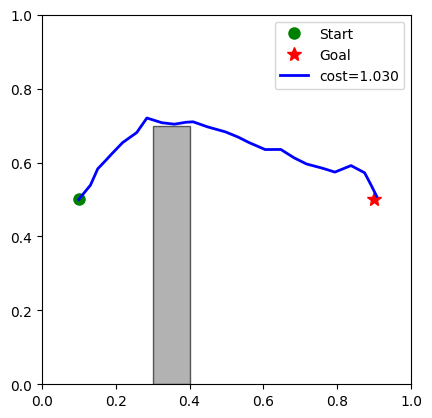

In [3]:
import matplotlib.pyplot as plt
from utils import Map, plot_map
from rrt_star import rrt_star

map_ = Map(x_lim=[0,1], y_lim=[0,1],
           obstacles=[[0.3, 0.0, 0.1, 0.7]])  # wall with gap at top

params = dict(max_iter=2000, step_size=0.05, gamma=1.0, goal_bias=0.05)

path, cost, t_init, n_init, cost_hist = rrt_star(
    map_, [0.1, 0.5], [0.9, 0.5], goal_radius=0.05, params=params)

fig, ax = plt.subplots()
plot_map(ax, map_, [0.1,0.5], [0.9,0.5])
if path is not None:
    ax.plot(path[:,0], path[:,1], 'b-', lw=2, label=f'cost={cost:.3f}')
ax.legend(); plt.show()

# Informed RRT* — Second Baseline Planner

## What is Informed RRT*?

Informed RRT* (Gammell et al., 2014) is a direct extension of RRT* that improves convergence speed by **restricting sampling to a subset of the configuration space** once an initial solution is found. The key insight is that any path better than the current best solution $c_\text{best}$ must pass through the *prolate hyperspheroid* — an ellipse in 2D — defined by the start and goal as its foci. Sampling outside this region can never improve the solution, so it is wasteful.

## The Informed Set

Once an initial feasible path of cost $c_\text{best}$ is found, all subsequent samples are drawn uniformly from the ellipsoidal informed set:

$$\mathcal{X}_f = \left\{ x \in \mathcal{X}_\text{free} \ \middle|\ \|x - x_\text{start}\| + \|x - x_\text{goal}\| \leq c_\text{best} \right\}$$

This ellipse has:
- **Foci** at $x_\text{start}$ and $x_\text{goal}$
- **Transverse semi-axis** $a = c_\text{best} / 2$
- **Conjugate semi-axis** $b = \sqrt{c_\text{best}^2 - c_\text{min}^2} / 2$, where $c_\text{min} = \|x_\text{goal} - x_\text{start}\|$

As the algorithm finds better solutions, $c_\text{best}$ decreases, the ellipse shrinks, and sampling becomes increasingly focused around the optimal path. Before any solution is found, Informed RRT* falls back to uniform sampling — identical to RRT*.

## How It Differs from RRT*

Informed RRT* and RRT* share **identical tree structure, parent selection, and rewiring logic**. The only difference is the sampling distribution used at each iteration:

| | Before first solution | After first solution |
|---|---|---|
| **RRT\*** | Uniform over $\mathcal{Q}_\text{free}$ | Uniform over $\mathcal{Q}_\text{free}$ |
| **Informed RRT\*** | Uniform over $\mathcal{Q}_\text{free}$ | Uniform over ellipsoidal set $\mathcal{X}_f$ |

This makes Informed RRT* a clean intermediate step between RRT* and Hybrid-RRT*, and ensures that any performance difference we observe in our experiments is attributable solely to the sampling strategy.

## What the Plots Show

The **left plot** shows the best path found after 2000 iterations on the same test environment as RRT* — a vertical wall with a gap at $y > 0.7$, with start at $[0.1, 0.5]$ and goal at $[0.9, 0.5]$.

The **right plot** shows the convergence of both RRT* and Informed RRT* over iterations. Key things to look for:
- Both algorithms find their first solution at roughly the same iteration (since both use uniform sampling until then)
- After the first solution, Informed RRT* should converge to a lower cost more quickly, as its samples are concentrated in the region that can actually improve the path
- The gap between the two curves widens over time, illustrating the benefit of informed sampling in open environments

## Limitations Relevant to Our Experiments

The informed ellipse assumes the optimal path lies roughly along the straight line between start and goal. In **narrow passage environments**, the true optimal path may deviate significantly from this line, causing the ellipse to exclude the passage entirely and slowing down or preventing improvement. This is one of the key failure modes we will investigate in our experiments.

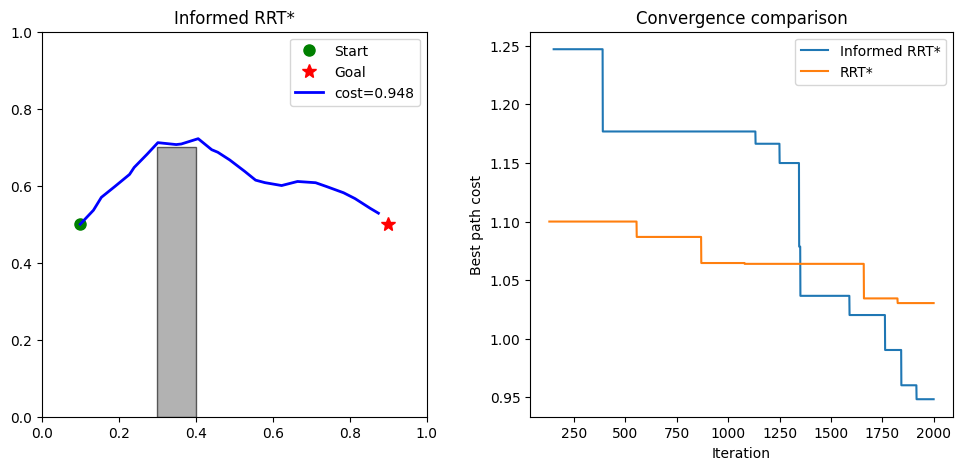

In [4]:
from informed_rrt_star import informed_rrt_star

path_i, cost_i, t_init_i, n_init_i, cost_hist_i = informed_rrt_star(
    map_, [0.1, 0.5], [0.9, 0.5], goal_radius=0.05, params=params)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: path
plot_map(axes[0], map_, [0.1,0.5], [0.9,0.5])
if path_i is not None:
    axes[0].plot(path_i[:,0], path_i[:,1], 'b-', lw=2, label=f'cost={cost_i:.3f}')
axes[0].set_title('Informed RRT*'); axes[0].legend()

# right: cost convergence vs RRT*
axes[1].plot(cost_hist_i, label='Informed RRT*')
axes[1].plot(cost_hist, label='RRT*')   # cost_history from the RRT* cell
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Best path cost')
axes[1].set_title('Convergence comparison'); axes[1].legend()
plt.show()

# RRT*-N — Third Baseline Planner

## What is RRT*-N?

RRT*-N (Mohammed et al., 2021) is a variant of RRT* that replaces uniform sampling with a **pure normal distribution** centred on the midpoint of the start-goal line. Unlike Hybrid-RRT*, there is no uniform fallback — every sample is drawn from the same normal distribution, making it the most aggressively goal-directed of the four planners.

## Sampling Strategy

At each iteration, a sample is drawn as:

$$q_\text{rand} \sim \mathcal{N}\!\left(\mu,\ \sigma^2\right), \quad \mu = \frac{q_\text{start} + q_\text{goal}}{2}, \quad \sigma = \frac{\|q_\text{goal} - q_\text{start}\|}{4}$$

Samples are clipped to map bounds. There is no uniform fallback.

## Role in Our Experiments

RRT*-N serves as the "pure non-uniform" extreme in our comparison. The four algorithms now span the full spectrum of sampling strategies:

| Algorithm | Sampling strategy |
|---|---|
| **RRT\*** | Pure uniform |
| **Informed RRT\*** | Uniform, then ellipse-restricted |
| **RRT\*-N** | Pure normal along start-goal line |
| **Hybrid RRT\*** | Mixture of uniform and normal |

RRT*-N is expected to be the fastest in open environments but the most brittle in narrow passage and high-density environments, since it has no mechanism to explore regions far from the start-goal line.

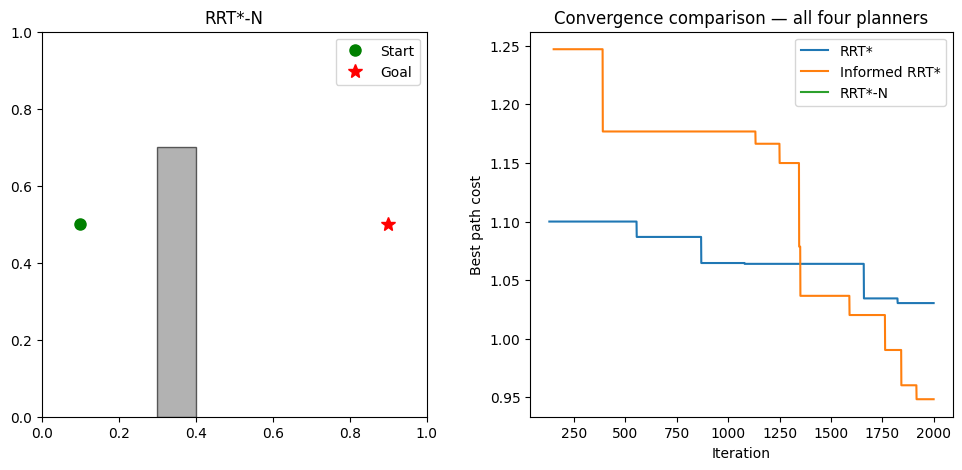

In [9]:
from rrt_star_n import rrt_star_n

path_n, cost_n, t_init_n, n_init_n, cost_hist_n = rrt_star_n(
    map_, [0.1, 0.5], [0.9, 0.5], goal_radius=0.05, params=params)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: path
plot_map(axes[0], map_, [0.1, 0.5], [0.9, 0.5])
if path_n is not None:
    axes[0].plot(path_n[:,0], path_n[:,1], 'b-', lw=2, label=f'cost={cost_n:.3f}')
axes[0].set_title('RRT*-N'); axes[0].legend()

# right: all four convergence curves
axes[1].plot(cost_hist,   label='RRT*')
axes[1].plot(cost_hist_i, label='Informed RRT*')
axes[1].plot(cost_hist_n, label='RRT*-N')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Best path cost')
axes[1].set_title('Convergence comparison — all four planners'); axes[1].legend()
plt.show()

# Hybrid RRT* — Algorithm Under Evaluation

## What is Hybrid RRT*?

Hybrid RRT* (Ganesan et al., 2024) is the primary algorithm under evaluation in this project. Like Informed RRT*, it improves upon RRT* by modifying the sampling distribution — but rather than using an ellipsoidal informed set, it uses a **mixture of uniform and goal-directed non-uniform sampling**, controlled by a mixing parameter $\alpha \in [0, 1]$.

The central claim of the paper is that this hybrid strategy achieves:
- **76.14% faster convergence** than RRT*
- **24% faster convergence** than Informed RRT*
- **48.53% fewer nodes explored** than RRT*

Our experiments investigate whether these claims hold under challenging conditions not fully characterized in the original paper.

## Sampling Strategy

At each iteration, a sample $q_\text{rand}$ is generated as follows:

$$q_\text{rand} = \begin{cases} q \sim \mathcal{U}(\mathcal{Q}_\text{free}) & \text{with probability } \alpha \\[6pt] \arg\min_{q \in \{q_u,\, q_n\}} \|q - q_\text{goal}\| & \text{with probability } 1 - \alpha \end{cases}$$

where in the non-uniform branch:
- $q_u \sim \mathcal{U}(\mathcal{Q}_\text{free})$ is a uniform sample
- $q_n \sim \mathcal{N}\!\left(\mu,\, \sigma^2\right)$ is a normal sample centred along the straight line between $q_\text{start}$ and $q_\text{goal}$, with $\mu = \frac{q_\text{start} + q_\text{goal}}{2}$ and $\sigma = \frac{\|q_\text{goal} - q_\text{start}\|}{4}$

The closer-to-goal sample is kept, biasing tree growth toward the goal while retaining enough randomness to ensure probabilistic completeness.

The parameter $\alpha$ controls the exploration-exploitation trade-off:
- $\alpha \to 1$: approaches pure uniform sampling (reduces to RRT*)
- $\alpha \to 0$: heavily goal-directed, faster in open environments but risks missing narrow passages

## How It Differs from RRT* and Informed RRT*

| | Sampling strategy | Requires initial solution? |
|---|---|---|
| **RRT\*** | Uniform over $\mathcal{Q}_\text{free}$ | No |
| **Informed RRT\*** | Uniform over ellipsoidal set $\mathcal{X}_f$ | Yes (falls back to uniform before) |
| **Hybrid RRT\*** | Mixture of uniform and normal along start-goal line | No |

A key distinction from Informed RRT* is that Hybrid-RRT* applies its directed sampling **from the very first iteration**, rather than waiting for an initial solution. This is intended to speed up the time-to-first-solution, not just the convergence rate afterward.

## What the Plots Show

The **left plot** shows the best path found by Hybrid-RRT* ($\alpha = 0.5$) on the same test environment as RRT* and Informed RRT*.

The **right plot** shows convergence curves for all three algorithms. Key things to look for:
- Hybrid-RRT* should reach its first solution earlier than RRT* and Informed RRT*, since its directed sampling begins immediately
- After the first solution, the convergence rate relative to Informed RRT* will depend on how well the start-goal line heuristic aligns with the true optimal path
- In this simple single-wall environment, Hybrid-RRT* should perform competitively — the interesting comparison comes in our narrow passage and high-density experiments

## Research Questions

Our experiments will specifically test:

1. **Narrow passages** — Does the normal distribution centred on the start-goal line cause Hybrid-RRT* to *miss* passages that deviate from the straight-line heuristic? We hypothesise that performance will degrade more sharply than RRT* as passage width $w$ decreases.

2. **High obstacle density** — Does the goal-directed bias help or hurt in cluttered environments where the straight-line heuristic is frequently blocked? We hypothesise that at high densities $\rho$, the advantage of Hybrid-RRT* over RRT* diminishes or reverses.

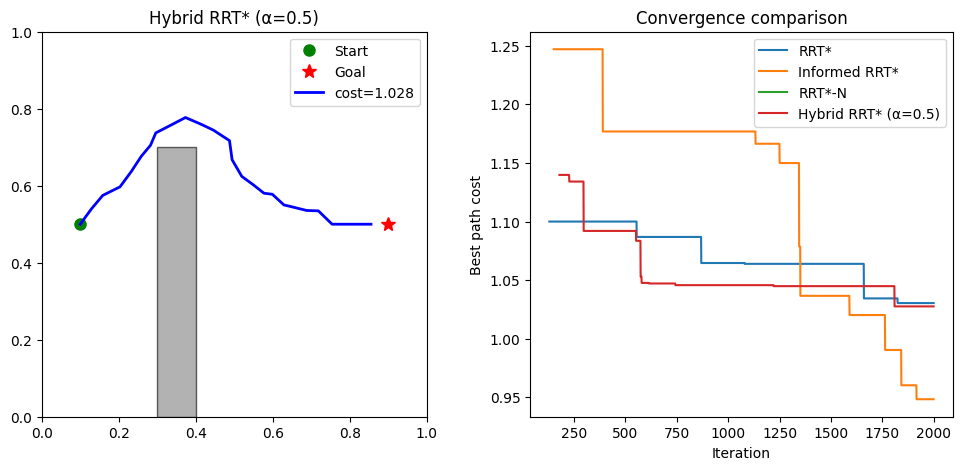

In [6]:
from hybrid_rrt_star import hybrid_rrt_star

params_h = {**params, 'alpha': 0.5}

path_h, cost_h, t_init_h, n_init_h, cost_hist_h = hybrid_rrt_star(
    map_, [0.1, 0.5], [0.9, 0.5], goal_radius=0.05, params=params_h)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: path
plot_map(axes[0], map_, [0.1, 0.5], [0.9, 0.5])
if path_h is not None:
    axes[0].plot(path_h[:,0], path_h[:,1], 'b-', lw=2, label=f'cost={cost_h:.3f}')
axes[0].set_title('Hybrid RRT* (α=0.5)'); axes[0].legend()

# right: all three convergence curves
axes[1].plot(cost_hist,   label='RRT*')
axes[1].plot(cost_hist_i, label='Informed RRT*')
axes[1].plot(cost_hist_n, label='RRT*-N')
axes[1].plot(cost_hist_h, label='Hybrid RRT* (α=0.5)')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Best path cost')
axes[1].set_title('Convergence comparison'); axes[1].legend()
plt.show()

# Experiments — Empirical Evaluation

## Overview

Having verified that all three planners work correctly on a simple test environment, we now conduct a rigorous empirical evaluation of their performance across two challenging environment types. Each experiment independently varies one environmental parameter while holding all others fixed, allowing us to isolate the effect of that parameter on planner performance.

All three algorithms use identical parameters across all experiments:

| Parameter | Value |
|---|---|
| `max_iter` | 2000 |
| `step_size` $\eta$ | 0.05 |
| `gamma` $\gamma$ | 1.0 |
| `goal_bias` | 0.05 |
| `alpha` (Hybrid RRT* only) | 0.5 |

For each condition, we run **50 independent trials** with different random seeds. Using multiple trials is essential because sampling-based planners are stochastic — a single run is not representative of typical performance.

---

## Experiment 1 — Narrow Passage Environments

**Research question:** Does Hybrid-RRT*'s goal-directed sampling hurt performance in narrow passage environments, where the optimal path deviates significantly from the straight-line heuristic?

**Environment:** A $[0,1]^2$ configuration space containing a single vertical wall centred at $x = 0.45$. The wall spans from $y = 0$ to $y = (1 - w)$, leaving a passage of width $w$ at the top of the map. The start is fixed at $[0.1, 0.5]$ and the goal at $[0.9, 0.5]$.

We vary passage width $w \in \{0.02,\ 0.05,\ 0.10,\ 0.20,\ 0.40\}$ (as a fraction of map height). Smaller values of $w$ make the passage harder to find.

**Hypothesis:** As $w$ decreases, Hybrid-RRT*'s non-uniform sampler — which concentrates samples along the horizontal start-goal line — will increasingly miss the passage located at the top of the map. We expect its success rate to degrade more sharply than RRT*, which samples uniformly and is therefore equally likely to find the passage regardless of its location.

---

## Experiment 2 — High Obstacle Density Environments

**Research question:** Does the relative advantage of Hybrid-RRT* over RRT* diminish or reverse as obstacle density increases?

**Environment:** A $[0,1]^2$ configuration space populated with randomly placed $0.08 \times 0.08$ rectangular obstacles. Obstacle density $\rho$ is defined as the fraction of the map area covered by obstacles. A fixed random seed per trial ensures all three algorithms are evaluated on identical maps.

We vary density $\rho \in \{0.10,\ 0.20,\ 0.30,\ 0.40,\ 0.50\}$. At $\rho = 0.50$, half the map is occupied by obstacles.

**Hypothesis:** At low densities, Hybrid-RRT*'s directed sampling provides a convergence advantage since the straight-line heuristic is unobstructed. At high densities, the straight line is frequently blocked, making the heuristic unreliable and potentially causing the algorithm to waste samples in collision regions — reducing or eliminating its advantage over RRT*.

---

## Metrics

For each trial we record:

- **Success rate** — fraction of trials that find a feasible solution within the iteration budget
- **Time to first solution** $t_\text{init}$ — wall-clock time until the first feasible path is found
- **Nodes at first solution** $n_\text{init}$ — tree size when the first solution is found (iteration-count analogue of $t_\text{init}$, independent of hardware)
- **Final path cost** $c^*$ — cost of the best path found at the end of all iterations
- **Convergence curve** $c^*(n)$ — best path cost as a function of samples drawn, averaged over all successful trials

All continuous metrics are reported as **median ± IQR** (interquartile range) over 50 trials, which is robust to the heavy-tailed distributions typical of sampling-based planners.

In [5]:
from run_experiments import (run_narrow_passage_experiment,
                              run_clutter_experiment, summarise)

params_full = dict(max_iter=2000, step_size=0.05,
                   gamma=1.0, goal_bias=0.05, alpha=0.5)

# quick smoke test with 3 trials before committing to 50
results_np = run_narrow_passage_experiment(
    passage_widths=[0.05, 0.10, 0.20],
    n_trials=3, # *********************************** TRIALS
    params=params_full
)

# print a summary for one condition
for key, trials in results_np.items():
    alg, w = key
    s = summarise(trials)
    print(f"{alg:20s}  w={w:.2f}  success={s['success_rate']:.0%}"
          f"  cost={s['cost_med']:.3f}  t_init={s['t_init_med']:.2f}s")

  [10/27] w=0.10  RRT*  trial 1
  [20/27] w=0.20  RRT*  trial 2
RRT*                  w=0.05  success=100%  cost=1.477  t_init=0.28s
Informed RRT*         w=0.05  success=100%  cost=1.501  t_init=0.27s
Hybrid RRT*           w=0.05  success=67%  cost=1.608  t_init=0.41s
RRT*                  w=0.10  success=100%  cost=1.505  t_init=0.06s
Informed RRT*         w=0.10  success=100%  cost=1.466  t_init=0.06s
Hybrid RRT*           w=0.10  success=100%  cost=1.700  t_init=0.15s
RRT*                  w=0.20  success=100%  cost=1.356  t_init=0.06s
Informed RRT*         w=0.20  success=100%  cost=1.444  t_init=0.06s
Hybrid RRT*           w=0.20  success=100%  cost=1.304  t_init=0.05s
